## Flagging Vendor Invoices for Manual Review

#### Objective: Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight or delivery patterns, in order to reduce financial risk, imporve operational efficiency and prioritize human review where it adds the most value.

 - Manual invoice review is time-consuming and does not scale with transaction volume.
 - Abnormla freight charges, pricing deviations or delivery delays often indicate errors, diputes or compliance risks.
 - An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically.

In [37]:
import pandas as pd 
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
conn = sqlite3.connect('/Users/ISHAAN BHASKAR/Documents/ML Project/data/inventory.db')
tables = pd.read_sql_query("Select name from sqlite_master where type='table'",conn)

In [39]:
for table in tables['name']:
    print(f"Table name: {table}")
    display(pd.read_sql(f"Select * from {table} limit 5",conn))

Table name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [40]:
purchase_agg_df = pd.read_sql_query("""
Select p.PONumber, count(distinct p.Brand) as total_brands,
                  sum(p.Quantity) as total_item_quantity,
                  sum(p.Dollars) as total_item_dollars,
                  avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
                  from purchases p
                  group by p.PONumber
""", conn)
purchase_agg_df

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271
...,...,...,...,...,...
5538,13657,3,253,3844.39,4.870968
5539,13658,111,14115,102949.38,5.016349
5540,13659,13,338,2492.20,4.735294
5541,13660,12,195,2599.66,4.611111


In [41]:
pd.read_sql_query("""
Select 
                  vi.Quantity as invoice_quantity,
                  vi.Dollars as invoice_dollars,
                  vi.Freight,
                  (julianday(vi.InvoiceDate) - julianday(vi.PODate)) as days_po_to_invoice,
                  (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) as days_to_pay
                  from vendor_invoice vi
                   """, conn)

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,6,214.26,3.47,14.0,43.0
1,15,140.55,8.57,16.0,45.0
2,5,106.60,4.61,16.0,38.0
3,10100,137483.78,2935.20,23.0,24.0
4,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,35.0
5539,4617,37300.48,186.50,18.0,39.0
5540,9848,202815.78,932.95,11.0,33.0
5541,24747,149007.56,819.54,14.0,36.0


In [42]:
df = pd.read_sql_query("""
                  WITH purchase_agg AS (
Select p.PONumber, count(distinct p.Brand) as total_brands,
                  sum(p.Quantity) as total_item_quantity,
                  sum(p.Dollars) as total_item_dollars,
                  avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
                  from purchases p
                  group by p.PONumber
                  )
                  Select vi.PONumber,
                  vi.Quantity as invoice_quantity,
                  vi.Dollars as invoice_dollars,
                  vi.Freight,
                  (julianday(vi.InvoiceDate) - julianday(vi.PODate)) as days_po_to_invoice,
                  (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) as days_to_pay,
                  pa.total_brands, pa.total_item_quantity, pa.total_item_dollars, pa.avg_receiving_delay
                  from vendor_invoice vi
                  Left Join purchase_agg pa
                  on vi.PONumber = pa.PONumber
                  """,conn)

In [43]:
df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [44]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [45]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [46]:
def create_invoice_risk_label(row):

    #Invoice total mismatch with item-level total
    if (abs(row['invoice_dollars'] - row['total_item_dollars']) > 5):
        return 1
    
    # Abnormally high receiving delay
    if row['avg_receiving_delay'] > 10:
        return 1
    
    return 0

df['flag_invoice'] = df.apply(create_invoice_risk_label, axis=1)
df['flag_invoice'].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

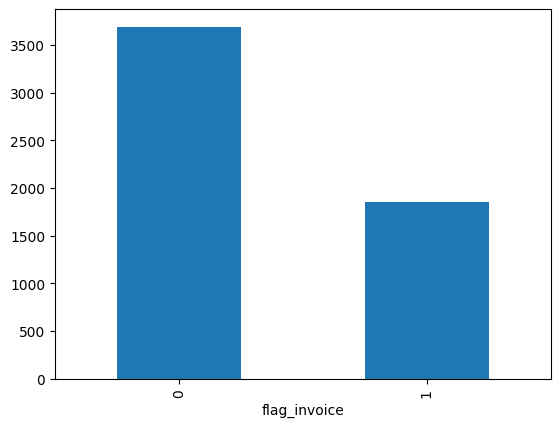

In [47]:
df['flag_invoice'].value_counts().plot(kind='bar')

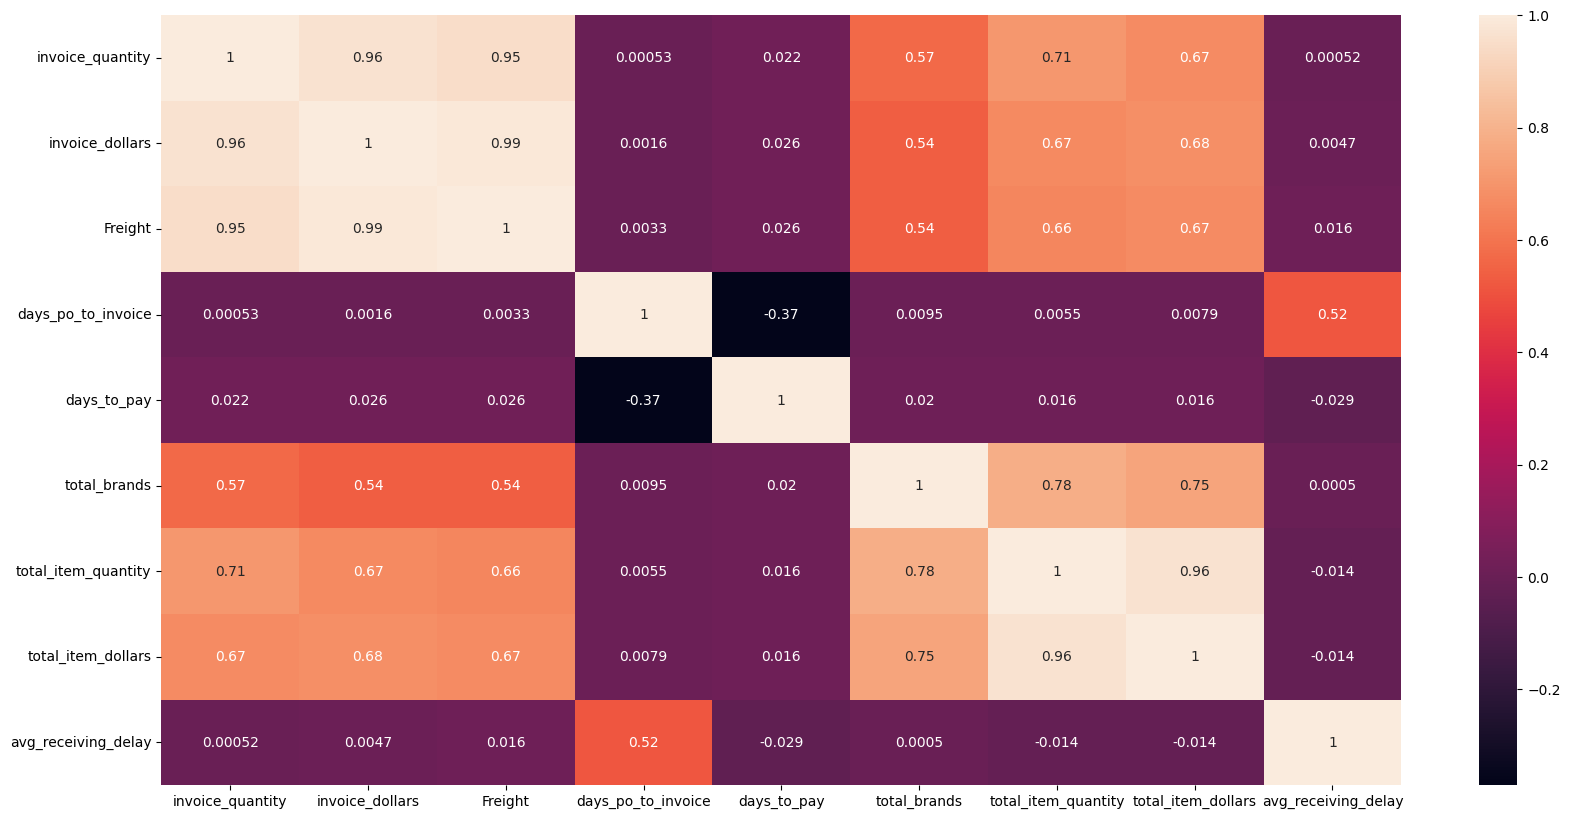

In [48]:
plt.figure(figsize=(20,10))
sns.heatmap(df.iloc[:,1:-1].corr(), annot=True)
plt.show()

In [49]:
flagged = df[df['flag_invoice']==1]
normal = df[df['flag_invoice']==0]

In [50]:
significant_features = []
non_significant_features = []
results = []

In [51]:
df.columns

Index(['PONumber', 'invoice_quantity', 'invoice_dollars', 'Freight',
       'days_po_to_invoice', 'days_to_pay', 'total_brands',
       'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay',
       'flag_invoice'],
      dtype='object')

In [52]:
metrics = ['invoice_quantity', 'invoice_dollars', 'Freight',
       'days_po_to_invoice', 'days_to_pay', 'total_brands',
       'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay']

In [53]:
from scipy.stats import ttest_ind

for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
            'metric':metric,
            'flagged_mean':flagged_mean.round(2),
            'normal_mean':normal_mean.round(2),
            'p_value':p_value.round(3)
        })
    else:
        non_significant_features.append(metric)

In [54]:
non_significant_features


['days_to_pay', 'total_brands']

In [55]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [56]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': 6728.28,
  'normal_mean': 5723.55,
  'p_value': 0.021},
 {'metric': 'invoice_dollars',
  'flagged_mean': 65600.61,
  'normal_mean': 54302.64,
  'p_value': 0.008},
 {'metric': 'Freight',
  'flagged_mean': 334.02,
  'normal_mean': 276.89,
  'p_value': 0.008},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': 17.23,
  'normal_mean': 16.02,
  'p_value': 0.0},
 {'metric': 'total_item_quantity',
  'flagged_mean': 6728.28,
  'normal_mean': 5723.55,
  'p_value': 0.021},
 {'metric': 'total_item_dollars',
  'flagged_mean': 65600.61,
  'normal_mean': 54302.64,
  'p_value': 0.008},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': 8.47,
  'normal_mean': 7.27,
  'p_value': 0.0}]

In [57]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight',
       'days_po_to_invoice', 'total_brands',
       'total_item_quantity', 'total_item_dollars']]
y = df['flag_invoice']

In [59]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [60]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [64]:
model1 = LogisticRegression(random_state=10)
model1.fit(X_train_scaled, y_train)

model2 = DecisionTreeClassifier(random_state=10)
model2.fit(X_train_scaled, y_train)

model3 = RandomForestClassifier(random_state=10)
model3.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=10)

In [66]:
from sklearn.metrics import accuracy_score, classification_report, make_scorer, f1_score

def evaluate_classfier(model, X_test, y_test, model_name):
    preds = model.predict(X_test)

    accuracy = accuracy_score(y_test, preds)
    report = classification_report(y_test, preds)

    print(f"\n{model_name} Performance")
    print(f"Accuracy: {accuracy:.2f}")
    print(report)

In [67]:
evaluate_classfier(model1, X_test_scaled, y_test, 'Logistic Regression')
evaluate_classfier(model2, X_test_scaled, y_test, 'Decision Tree Classifier')
evaluate_classfier(model3, X_test_scaled, y_test, 'Random Forest Classifier')


Logistic Regression Performance
Accuracy: 0.68
              precision    recall  f1-score   support

           0       0.69      0.98      0.81       749
           1       0.61      0.07      0.13       360

    accuracy                           0.68      1109
   macro avg       0.65      0.53      0.47      1109
weighted avg       0.66      0.68      0.59      1109


Decision Tree Classifier Performance
Accuracy: 0.81
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       749
           1       0.71      0.69      0.70       360

    accuracy                           0.81      1109
   macro avg       0.78      0.78      0.78      1109
weighted avg       0.81      0.81      0.81      1109


Random Forest Classifier Performance
Accuracy: 0.87
              precision    recall  f1-score   support

           0       0.86      0.97      0.91       749
           1       0.91      0.66      0.77       360

    accuracy                

In [68]:
model3.feature_importances_

array([0.1490531 , 0.14470822, 0.13130629, 0.07501427, 0.08675257,
       0.19041033, 0.22275523])

In [69]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model3.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance

,feature,importance
6,total_item_dollars,0.222755
5,total_item_quantity,0.190410
0,invoice_quantity,0.149053
1,invoice_dollars,0.144708
2,Freight,0.131306
4,total_brands,0.086753
3,days_po_to_invoice,0.075014


In [70]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight',
       'total_item_quantity', 'total_item_dollars']]
y = df['flag_invoice']

In [72]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [73]:
model3 = RandomForestClassifier(random_state=10)
model3.fit(X_train_scaled, y_train)

evaluate_classfier(model3, X_test_scaled, y_test, 'Random Forest Classifier')


Random Forest Classifier Performance
Accuracy: 0.87
              precision    recall  f1-score   support

           0       0.87      0.96      0.91       749
           1       0.88      0.70      0.78       360

    accuracy                           0.87      1109
   macro avg       0.88      0.83      0.84      1109
weighted avg       0.87      0.87      0.87      1109



In [74]:
param_grid = {
    'n_estimators': [100,200,300],
    'max_depth': [None,4,5,6],
    'min_samples_split': [2,3,5],
    'min_samples_leaf': [1,2,5],
    'criterion': ['gini', 'entropy']}

In [75]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(random_state=10, n_jobs=-1)


scorer = make_scorer(f1_score)
grid_search = GridSearchCV(estimator=rf,
                           param_grid=param_grid,
                           scoring=scorer,
                           cv=5,
                           verbose=2,
                           n_jobs=-1)

grid_search.fit(X_train_scaled, y_train)
evaluate_classfier(grid_search, X_test_scaled, y_test, "Random Forest Classifier")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Random Forest Classifier Performance
Accuracy: 0.88
              precision    recall  f1-score   support

           0       0.87      0.96      0.91       749
           1       0.90      0.70      0.79       360

    accuracy                           0.88      1109
   macro avg       0.88      0.83      0.85      1109
weighted avg       0.88      0.88      0.87      1109



In [76]:
from sklearn.metrics import confusion_matrix

In [77]:
confusion_matrix(grid_search.predict(X_test_scaled), y_test)

array([[720, 108],
       [ 29, 252]], dtype=int64)

In [78]:
confusion_matrix(model3.predict(X_test_scaled), y_test)

array([[716, 109],
       [ 33, 251]], dtype=int64)

In [79]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}